# 🔥 CrisisOps v2 — GRPO Training Notebook

Train an LLM to detect deceptive software engineers and recover failing projects.

**One-click training in Colab** — No setup required. Run cells top to bottom.

## What you'll see:
- 📊 Real-time reward curves (agent vs. greedy baseline)
- 🎯 Cross-verification rate (how often agent checks signals)
- 📈 Training convergence plots
- 🤖 Interactive evaluation of trained agent
- 💾 Checkpoint saving & loading

**Time:** ~45 minutes on T4 GPU for full training (250 episodes)

In [1]:
# Cell 1: Install dependencies (with version pinning)
import sys, subprocess

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
    print(f"✓ Installed {package}")

print("🚀 Installing required packages...\n")

packages = [
    "unsloth", "trl>=0.14.0", "transformers>=4.46.0", "datasets>=3.2.0",
    "accelerate>=1.1.0", "peft>=0.13.0", "matplotlib>=3.9.0", "seaborn>=0.13.0",
    "pandas>=2.2.0", "numpy>=1.26.0", "wandb", "tqdm", "ipywidgets", "scipy"
]

for pkg in packages:
    try:
        install_package(pkg)
    except:
        print(f"⚠️ Retrying {pkg} without version...")
        install_package(pkg.split(">=")[0])

print("\n✅ All packages installed successfully!")
print(f"Python version: {sys.version}")

import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
print("✅ WANDB disabled and tokenizer parallelism set")


🚀 Installing required packages...

✓ Installed unsloth
✓ Installed trl>=0.14.0
✓ Installed transformers>=4.46.0
✓ Installed datasets>=3.2.0
✓ Installed accelerate>=1.1.0
✓ Installed peft>=0.13.0
✓ Installed matplotlib>=3.9.0
✓ Installed seaborn>=0.13.0
✓ Installed pandas>=2.2.0
✓ Installed numpy>=1.26.0
✓ Installed wandb
✓ Installed tqdm
✓ Installed ipywidgets
✓ Installed scipy

✅ All packages installed successfully!
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
✅ WANDB disabled and tokenizer parallelism set


In [2]:
# Cell 2: Clone or create CrisisOps environment
import os, sys, shutil
from pathlib import Path

# Detect Colab
IN_COLAB = 'google.colab' in str(get_ipython())

# Optional persistent checkpoints in Colab
if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        print("✅ Google Drive mounted")
    except Exception as e:
        print(f"⚠️ Drive mount skipped: {e}")

REPO_URL = "https://github.com/vedchamp07/crisisops"

if IN_COLAB:
    repo_path = "/content/crisisops"
    if os.path.exists(repo_path):
        shutil.rmtree(repo_path)
    os.chdir("/content")  # fix getcwd error after runtime reset
    print("📥 Cloning CrisisOps repository...")
    !git clone {REPO_URL} {repo_path}
    if not os.path.exists(os.path.join(repo_path, "env")):
        raise RuntimeError("Clone failed — check REPO_URL and repo structure")
    os.chdir(repo_path)
else:
    repo_path = os.getcwd()
    print(f"📍 Local environment: {repo_path}")

sys.path.insert(0, repo_path)
os.environ['PYTHONPATH'] = repo_path + ':' + os.environ.get('PYTHONPATH', '')

checkpoint_root = "/content/drive/MyDrive/crisisops_checkpoints" if IN_COLAB else "./checkpoints"
Path(checkpoint_root).mkdir(parents=True, exist_ok=True)
Path("./logs").mkdir(exist_ok=True)
Path("./figures").mkdir(exist_ok=True)

print(f"✅ Working directory: {os.getcwd()}")
print(f"📁 Contents: {os.listdir('.')[:8]}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted
📥 Cloning CrisisOps repository...
Cloning into '/content/crisisops'...
remote: Enumerating objects: 4304, done.
remote: Counting objects: 100% (4304/4304), done.
remote: Compressing objects: 100% (3093/3093), done.
remote: Total 4304 (delta 1160), reused 4249 (delta 1108), pack-reused 0 (from 0)
Receiving objects: 100% (4304/4304), 22.61 MiB | 14.84 MiB/s, done.
Resolving deltas: 100% (1160/1160), done.
✅ Working directory: /content/crisisops
📁 Contents: ['pyproject.toml', 'training', 'requirements.txt', 'app.py', 'README.md', 'figures', 'tests', '.gitignore']


In [3]:
# Cell 3: Verify and import CrisisOps modules
import numpy as np
import torch

print("🔍 Verifying environment modules...\n")

try:
    from env.environment import CrisisOpsEnv
    from reward.baseline import GreedyPMBaseline
    print("  ✓ CrisisOpsEnv imported")
    print("  ✓ GreedyPMBaseline imported")
except Exception as e:
    raise RuntimeError(f"Failed to import env modules: {e}")

print("\n✅ Verification complete")


🔍 Verifying environment modules...

  ✓ CrisisOpsEnv imported
  ✓ GreedyPMBaseline imported

✅ Verification complete


📊 Running calibration over 30 matched episodes...


100%|██████████| 30/30 [00:00<00:00, 98.59it/s] 
/tmp/ipykernel_10912/2545700570.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([greedy_scores, oracle_scores], labels=['Greedy', 'Oracle'])


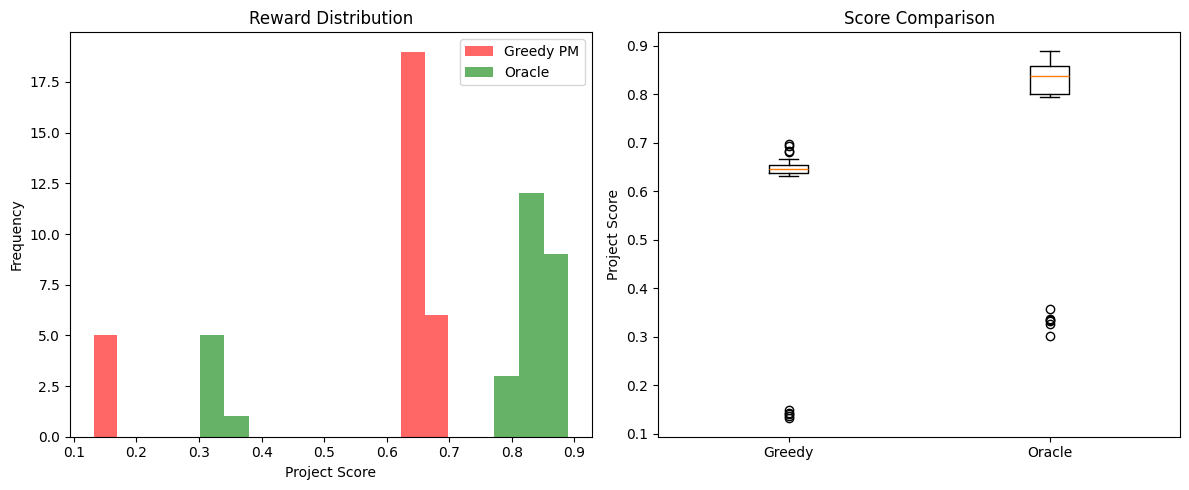


📈 Calibration Results:
Greedy PM: 0.569 ± 0.192
Oracle:    0.741 ± 0.206
Gap:       0.173


In [4]:
# Cell 4: Calibration (greedy vs oracle)
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from calibration.calibrate import OracleAgent
from env.environment import CrisisOpsEnv, MAX_STEPS
from reward.baseline import GreedyPMBaseline
from reward.counterfactual import project_score
from scenarios.level1 import LEVEL1_SCENARIOS


def _run_policy_episode(env, policy, is_oracle=False):
    """Run one episode and return final raw project_score."""
    done = False
    step = 0
    while not done and step < MAX_STEPS:
        if is_oracle:
            action = policy.act(env._state, env)
        else:
            action = policy.act(env._state)
        _, _, done, _ = env.step(action)
        step += 1
    return project_score(env._state)


def run_calibration(n_episodes=30, seed=1000):
    """Notebook calibration aligned with calibration/calibrate.py logic."""
    greedy_scores = []
    oracle_scores = []

    print(f"📊 Running calibration over {n_episodes} matched episodes...")
    for ep in tqdm(range(n_episodes)):
        seed_i = seed + ep

        # Match scenario per seed so greedy/oracle face identical starts.
        scenario_rng = random.Random(seed_i)
        scenario_fn = LEVEL1_SCENARIOS[
            scenario_rng.randint(0, len(LEVEL1_SCENARIOS) - 1)
        ]

        greedy_env = CrisisOpsEnv(scenario_fn=scenario_fn, curriculum_level=1)
        greedy_env.reset(seed=seed_i)
        greedy_scores.append(_run_policy_episode(greedy_env, GreedyPMBaseline(), is_oracle=False))

        oracle_env = CrisisOpsEnv(scenario_fn=scenario_fn, curriculum_level=1)
        oracle_env.reset(seed=seed_i)
        oracle_scores.append(_run_policy_episode(oracle_env, OracleAgent(), is_oracle=True))

    return np.array(greedy_scores), np.array(oracle_scores)


greedy_scores, oracle_scores = run_calibration(n_episodes=30, seed=1000)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.hist(greedy_scores, bins=15, alpha=0.6, label='Greedy PM', color='red')
ax1.hist(oracle_scores, bins=15, alpha=0.6, label='Oracle', color='green')
ax1.set_xlabel('Project Score')
ax1.set_ylabel('Frequency')
ax1.set_title('Reward Distribution')
ax1.legend()

ax2.boxplot([greedy_scores, oracle_scores], labels=['Greedy', 'Oracle'])
ax2.set_ylabel('Project Score')
ax2.set_title('Score Comparison')
plt.tight_layout()
plt.savefig('./figures/calibration.png', dpi=100)
plt.show()

print(f"\n📈 Calibration Results:")
print(f"Greedy PM: {greedy_scores.mean():.3f} ± {greedy_scores.std():.3f}")
print(f"Oracle:    {oracle_scores.mean():.3f} ± {oracle_scores.std():.3f}")
print(f"Gap:       {oracle_scores.mean() - greedy_scores.mean():.3f}")

if oracle_scores.mean() < greedy_scores.mean():
    raise RuntimeError(
        "Oracle mean is below Greedy mean. This indicates a calibration logic issue."
    )


gap = oracle_scores.mean() - greedy_scores.mean()

In [5]:
# Cell 5: Training configuration
from dataclasses import dataclass, field

@dataclass
class Config:
    model_name:       str   = "Qwen/Qwen2.5-1.5B-Instruct"
    lora_r:           int   = 16
    lora_alpha:       int   = 32
    learning_rate:    float = 2e-5
    num_episodes:     int   = 300       # 300 x G=4 = 1200 episodes on Colab T4
    curriculum_level: int   = 1
    seed:             int   = 42
    temperature:      float = 0.3       # used only if use_sampling=True
    save_every:       int   = 25
    output_dir:       str   = "/content/drive/MyDrive/crisisops_checkpoints"
    use_sampling:     bool  = False     # avoid CUDA multinomial instability on Colab T4
    epsilon_explore:  float = 0.12      # explicit exploration without sampling in generate()
    log_every:        int   = 1         # per-update logs for visibility

    # ── GRPO / variance-reduction knobs ──────────────────────────────────
    G:                int   = 4         # rollouts per gradient update (GRPO group size)
    verif_bonus:      float = 0.04      # per-step reward for query_observable_signals / query_member_report
    baseline_alpha:   float = 0.05      # EMA decay for running reward baseline
    min_group_std:    float = 0.01      # lower threshold so GRPO mode is used more often

config = Config()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")
else:
    print("   ⚠️  No GPU — training will be slow")


🖥️  Device: cuda
   GPU: Tesla T4
15.637086208 GB


In [ ]:
# Cell 6: Observation sanity check (run before training)
'''
from env.environment import CrisisOpsEnv
from transformers import AutoTokenizer

_VALID_ACTIONS_SANITY = [
    "query_status", "query_member_report", "query_observable_signals", "query_ticket",
    "reassign_task", "communicate", "cut_scope", "escalate_risk",
    "request_resource", "update_timeline", "consult_expert",
    "resolve_blocker", "submit_recovery_plan",
]

_check_env = CrisisOpsEnv()
_obs = _check_env.reset(seed=42)

_check_tokenizer = AutoTokenizer.from_pretrained(config.model_name)
_action_block = "\n".join(f"  {a}" for a in _VALID_ACTIONS_SANITY)
_prompt = (
    f"You are a PM recovering a failing software project.\n"
    f"State: tasks={_obs.get('tasks', [])}, team={_obs.get('team_members', [])}, budget={_obs.get('budget_remaining', 20)}\n"
    f"Valid actions:\n{_action_block}\n"
    f"Reply with EXACTLY ONE action name from the list above.\n"
    f"Action:"
)
_tokens = _check_tokenizer(_prompt, return_tensors="pt", truncation=True, max_length=1800)
print(f"Prompt token length: {_tokens['input_ids'].shape[1]}")
print("First 400 chars:\n" + _prompt[:400])
assert _tokens['input_ids'].shape[1] < 1800, "Prompt too long — shorten format_obs()"
print("✅ Observation format OK")
'''

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Prompt token length: 151
First 400 chars:
You are a PM recovering a failing software project.
State: tasks=[], team=[{'member_id': 'dev_1', 'name': 'Alice', 'role': 'engineer', 'reported_completion': 0.73, 'reported_availability': 0.8, 'assigned_task_ids': ['task_1']}], budget=20
Valid actions:
  query_status
  query_member_report
  query_observable_signals
  query_ticket
  reassign_task
  communicate
  cut_scope
  escalate_risk
  request
✅ Observation format OK


In [ ]:
# Cell 7: Training loop — GRPO with variance reduction
import time
import random
import torch
import torch.nn.functional as F
import torch.optim as optim
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model
from scenarios.level1 import LEVEL1_SCENARIOS

VALID_ACTIONS = [
    "query_status", "query_member_report", "query_observable_signals", "query_ticket",
    "reassign_task", "communicate", "cut_scope", "escalate_risk",
    "request_resource", "update_timeline", "consult_expert",
    "resolve_blocker", "submit_recovery_plan",
]
FREE_ACTIONS = {"query_status", "query_member_report", "query_observable_signals", "query_ticket"}
VERIF_ACTIONS = {"query_observable_signals", "query_member_report"}  # directly rewarded
VALID_ACTIONS_SET = set(VALID_ACTIONS)

def format_reward(action_str):
    return 0.1 if action_str.strip() in VALID_ACTIONS_SET else -0.1


class Trainer:
    def __init__(self, config):
        self.config = config

        self.greedy = GreedyPMBaseline()

        print(f"Loading {config.model_name}...")
        dtype = torch.float16 if torch.cuda.is_available() else torch.float32
        self.model = AutoModelForCausalLM.from_pretrained(
            config.model_name,
            torch_dtype=dtype,
            low_cpu_mem_usage=True,
            attn_implementation="eager",  # avoids fragile SDPA kernels on Colab T4
        )
        self.tokenizer = AutoTokenizer.from_pretrained(config.model_name)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        lora_cfg = LoraConfig(
            r=config.lora_r,
            lora_alpha=config.lora_alpha,
            target_modules=["q_proj", "v_proj"],
            lora_dropout=0.05,
            bias="none",
            task_type="CAUSAL_LM",
        )
        self.model = get_peft_model(self.model, lora_cfg)
        self.model = self.model.to(device)
        self.model.train()
        self.model.print_trainable_parameters()

        # Hard-force greedy decoding on Colab T4 to avoid CUDA multinomial asserts.
        self.config.use_sampling = False
        self.model.generation_config.do_sample = False
        if hasattr(self.model.generation_config, "temperature"):
            self.model.generation_config.temperature = None
        if hasattr(self.model.generation_config, "top_p"):
            self.model.generation_config.top_p = None
        if hasattr(self.model.generation_config, "top_k"):
            self.model.generation_config.top_k = None
        self._generate_fallbacks = 0

        self.optimizer = optim.AdamW(
            [p for p in self.model.parameters() if p.requires_grad],
            lr=config.learning_rate,
        )

        # First token id for each action (for log-prob targeting)
        self._action_tok = {}
        for a in VALID_ACTIONS:
            ids = self.tokenizer.encode(" " + a, add_special_tokens=False)
            if ids:
                self._action_tok[a] = ids[0]

        # ── Running baseline for variance reduction (EMA of cf_rewards) ──
        # Subtracting this from each episode's reward before the gradient
        # update means the model only receives a meaningful signal when it
        # actually beats its own recent average — not just when cf_reward
        # happens to be positive due to greedy-score noise.
        self._reward_baseline = 0.0

        # Metrics
        self.episode_rewards        = []
        self.counterfactual_rewards = []
        self.cross_verification     = []
        self.losses                 = []
        self._fallback_counter      = 0

    # ── Prompt ────────────────────────────────────────────────────────────
    def format_obs(self, obs):
        budget  = obs.get("budget_remaining", obs.get("budget", 20))
        tasks   = obs.get("tasks", [])
        members = obs.get("team_members", [])

        if budget <= 4:
            hint = "Budget critically low — use submit_recovery_plan NOW."
        elif budget <= 8:
            hint = "Budget low — prefer: reassign_task, resolve_blocker, submit_recovery_plan."
        else:
            hint = "Query signals for each member first, then act decisively."

        action_block = "\n".join(f"  {a}" for a in VALID_ACTIONS)
        return (
            f"You are a PM recovering a failing software project.\n"
            f"State: tasks={tasks}, team={members}, budget={budget}\n"
            f"Hint: {hint}\n"
            f"Valid actions:\n{action_block}\n"
            f"Reply with EXACTLY ONE action name from the list above.\n"
            f"Action:"
        )

    # ── Action parser ─────────────────────────────────────────────────────
    def _parse_action(self, text, budget):
        t = text.lower().strip()
        for a in VALID_ACTIONS:
            if t == a:
                return a
        hits = [a for a in VALID_ACTIONS if a in t]
        if hits:
            return max(hits, key=len)
        if budget <= 4:
            return "submit_recovery_plan"
        paid = [a for a in VALID_ACTIONS if a not in FREE_ACTIONS]
        action = paid[self._fallback_counter % len(paid)]
        self._fallback_counter += 1
        return action

    def _scenario_fn_for_seed(self, seed):
        """Pick a deterministic level-1 scenario from seed."""
        rng = random.Random(seed)
        idx = rng.randint(0, len(LEVEL1_SCENARIOS) - 1)
        return LEVEL1_SCENARIOS[idx]

    def _make_env(self, seed):
        return CrisisOpsEnv(
            scenario_fn=self._scenario_fn_for_seed(seed),
            curriculum_level=self.config.curriculum_level,
        )

    def _log_prob_for_action(self, obs, action):
      model_dev = next(self.model.parameters()).device
      prompt = self.format_obs(obs)
      inputs = self.tokenizer(
          prompt, return_tensors="pt",
          truncation=True, max_length=1800,
      ).to(model_dev)

      target_tok = self._action_tok.get(action, self.tokenizer.eos_token_id)
      vocab_size = int(self.model.config.vocab_size)
      if not (0 <= int(target_tok) < vocab_size):
          target_tok = int(self.tokenizer.eos_token_id)

      target_ids = torch.tensor(
          [[int(target_tok)]], device=model_dev,
          dtype=inputs["input_ids"].dtype
      )
      full_ids = torch.cat([inputs["input_ids"], target_ids], dim=1)

      # NO torch.no_grad() here — we need gradients to flow
      logits = self.model(full_ids).logits.float()
      log_probs = F.log_softmax(logits[0, -2, :], dim=-1)
      log_prob = log_probs[int(target_tok)]

      if torch.isnan(log_prob) or torch.isinf(log_prob):
          log_prob = torch.tensor(
              -10.0, device=model_dev,
              dtype=torch.float32, requires_grad=True
          )
      return log_prob

    def _build_action_payload(self, action, obs):
        """Build valid params for actions to avoid no-op errors."""
        members = obs.get("team_members", [])
        member_ids = [m.get("member_id") for m in members if isinstance(m, dict) and m.get("member_id")]
        crises = obs.get("crises", [])

        first_member = member_ids[0] if member_ids else "dev_1"
        best_member = first_member
        if members:
            try:
                best_member = max(
                    [m for m in members if isinstance(m, dict)],
                    key=lambda m: float(m.get("reported_availability", 0.0)),
                ).get("member_id", first_member)
            except Exception:
                best_member = first_member

        task_id = "task_1"
        for c in crises:
            if isinstance(c, dict) and c.get("affected_task_ids"):
                task_id = c["affected_task_ids"][0]
                break

        if action == "query_member_report":
            return {"action_type": action, "params": {"member_id": first_member}}
        if action == "query_observable_signals":
            return {"action_type": action, "params": {"member_id": first_member}}
        if action == "query_ticket":
            return {"action_type": action, "params": {"task_id": task_id}}
        if action == "communicate":
            return {
                "action_type": action,
                "params": {
                    "message_type": "proactive_escalation_with_plan",
                    "content": "Investigating blockers and reallocating resources.",
                    "target": "both",
                },
            }
        if action == "reassign_task":
            return {
                "action_type": action,
                "params": {
                    "task_id": task_id,
                    "to_member_id": best_member,
                },
            }
        if action == "submit_recovery_plan":
            return {
                "action_type": action,
                "params": {
                    "plan_summary": "Recovery plan based on latest signals.",
                    "risk_items": [],
                    "timeline": "2 weeks",
                },
            }

        return {"action_type": action, "params": {}}

    # ── Sample one action + log-prob ─────────────────────────────────────
    def sample_action(self, obs):
        prompt = self.format_obs(obs)
        model_dev = next(self.model.parameters()).device
        inputs = self.tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=1800,
        ).to(model_dev)
        input_len = inputs["input_ids"].shape[1]

        # Always greedy decode in-kernel; explore explicitly in Python below.
        gen_kwargs = {
            "max_new_tokens": 10,
            "do_sample": False,
            "num_beams": 1,
            "pad_token_id": self.tokenizer.eos_token_id,
            "eos_token_id": self.tokenizer.eos_token_id,
        }

        try:
            with torch.no_grad():
                out = self.model.generate(**inputs, **gen_kwargs)
            new_tokens = out[0][input_len:]
            action_text = self.tokenizer.decode(new_tokens, skip_special_tokens=True)
            action = self._parse_action(action_text, obs.get("budget_remaining", obs.get("budget", 20)))
        except Exception:
            # If generation fails for any reason, keep training alive with a safe fallback.
            self._generate_fallbacks += 1
            budget = obs.get("budget_remaining", obs.get("budget", 20))
            if budget <= 4:
                action = "submit_recovery_plan"
            else:
                paid = [a for a in VALID_ACTIONS if a not in FREE_ACTIONS and a != "submit_recovery_plan"]
                action = paid[self._fallback_counter % len(paid)]
                self._fallback_counter += 1

        # Stable exploration path: avoid CUDA multinomial by sampling actions in Python.
        if random.random() < self.config.epsilon_explore:
            budget = obs.get("budget_remaining", obs.get("budget", 20))
            if budget <= 4:
                action = "submit_recovery_plan"
            else:
                paid = [a for a in VALID_ACTIONS if a not in FREE_ACTIONS and a != "submit_recovery_plan"]
                action = random.choice(paid)

        with torch.enable_grad():
          log_prob = self._log_prob_for_action(obs, action)
        print(f"log_prob.grad_fn after sample_action: {log_prob.grad_fn}, model.training: {self.model.training}")

        return action, log_prob

    # ── Run one rollout, return shaped cf_reward + log_probs ─────────────
    def rollout(self, seed):
        """
        Runs one episode from the given seed.

        Returns:
          cf_reward   : float  — shaped counterfactual reward
          log_probs   : list[Tensor] — one log-prob per step
          actions     : list[str]
        """
        env = self._make_env(seed)
        obs = env.reset(seed=seed)
        done = False
        actions, log_probs = [], []
        step_rewards = 0.0
        free_streak = 0

        while not done:
            action, lp = self.sample_action(obs)

            # Prevent free-query loops before env forced-action kicks in.
            if free_streak >= 4 and action in FREE_ACTIONS:
                action = "communicate"
                lp = self._log_prob_for_action(obs, action)

            action_payload = self._build_action_payload(action, obs)

            actions.append(action)
            log_probs.append(lp)

            obs, _, done, info = env.step(action_payload)

            if action in FREE_ACTIONS and not obs.get("error"):
                free_streak += 1
            elif not obs.get("error"):
                free_streak = 0

            # ── Per-step verification bonus ───────────────────────────────
            # Directly reward the signal-checking actions so CVR can't be
            # trained to zero by noisy episode-level rewards.
            if action in VERIF_ACTIONS and not obs.get("error"):
                step_rewards += self.config.verif_bonus

        from reward.counterfactual import project_score as _ps
        proj_score = _ps(env._state)
        g_score = self._greedy_score(seed)
        episode_format_bonus = sum(format_reward(a) for a in actions) / max(1, len(actions))
        cf_reward = (proj_score - g_score) + step_rewards + episode_format_bonus

        return cf_reward, log_probs, actions

    def _greedy_score(self, seed):
        env = self._make_env(seed)
        obs = env.reset(seed=seed)
        done = False
        while not done:
            obs, _, done, info = env.step(self.greedy.act(env._state))
        from reward.counterfactual import project_score as _ps
        return _ps(env._state)

    def compute_cvr(self, actions):
        verif = {"query_observable_signals", "query_member_report", "query_status", "query_ticket"}
        return sum(1 for a in actions if a in verif) / max(1, len(actions))

    # ── GRPO update: G rollouts, centred advantages ───────────────────────
    def grpo_update(self, ep_idx):
        """
        Collect G rollouts from the same starting seed.
        Advantage = (cf_reward - mean(cf_rewards across G rollouts)) / std.
        This within-group centering is the GRPO objective.

        We also track an EMA reward baseline for logging/diagnostics only.
        """
        G    = self.config.G
        base_seed = self.config.seed + ep_idx * G

        cf_rewards_g = []
        log_probs_g  = []
        actions_g    = []

        for g in range(G):
            cf, lps, acts = self.rollout(base_seed + g)
            cf_rewards_g.append(cf)
            log_probs_g.append(lps)
            actions_g.extend(acts)

        cf_arr = torch.tensor(cf_rewards_g, dtype=torch.float32)

        # ── Within-group centering (GRPO) ─────────────────────────────────
        group_mean = cf_arr.mean()
        group_std_raw = cf_arr.std(unbiased=False)
        group_std = group_std_raw.clamp(min=1e-6)

        # ── EMA running baseline (monitoring + fallback centering) ────────
        prev_baseline = float(self._reward_baseline)
        self._reward_baseline = (
            (1 - self.config.baseline_alpha) * self._reward_baseline
            + self.config.baseline_alpha * group_mean.item()
        )

        # If rollouts are nearly identical, GRPO advantages collapse to ~0.
        # Fall back to an EMA-baseline signal so updates do not stall.
        if group_std_raw.item() < self.config.min_group_std:
            advantages = cf_arr - prev_baseline
            adv_mode = "ema_fallback"
        else:
            advantages = (cf_arr - group_mean) / group_std
            adv_mode = "grpo"

        # ── Policy gradient loss across all G rollouts ────────────────────
        model_dev = next(self.model.parameters()).device
        total_loss = torch.tensor(0.0, device=model_dev, requires_grad=False)
        abs_loss_sum = torch.tensor(0.0, device=model_dev, requires_grad=False)
        nonempty_rollouts = 0
        self.optimizer.zero_grad()

        for g in range(G):
            adv = advantages[g].item()
            lps = log_probs_g[g]
            if not lps:
                continue
            lp_stack = torch.stack(lps)            # (T,) float32
            # Normalise by episode length so short/long episodes have equal
            # gradient magnitude — fixes the loss-scale variance.
            mean_lp  = lp_stack.mean()
            loss_g   = -(adv * mean_lp)            # REINFORCE, length-normalised
            loss_g.backward()
            total_loss = total_loss + loss_g.detach()
            abs_loss_sum = abs_loss_sum + loss_g.detach().abs()
            nonempty_rollouts += 1

        params = [p for p in self.model.parameters() if p.requires_grad]
        grad_norm = float(torch.nn.utils.clip_grad_norm_(params, max_norm=1.0))
        self.optimizer.step()

        denom = max(1, nonempty_rollouts)
        signed_loss = total_loss.item() / denom
        abs_loss = abs_loss_sum.item() / denom

        avg_cf = cf_arr.mean().item()
        avg_cvr = self.compute_cvr(actions_g)
        diagnostics = {
            "group_std": float(group_std_raw.item()),
            "group_mean": float(group_mean.item()),
            "adv_mode": adv_mode,
            "cf_rewards": [float(x) for x in cf_rewards_g],
            "signed_loss": float(signed_loss),
            "abs_loss": float(abs_loss),
            "grad_norm": grad_norm,
            "nonempty_rollouts": int(nonempty_rollouts),
        }
        return avg_cf, avg_cvr, abs_loss, diagnostics

    # ── Training loop ─────────────────────────────────────────────────────
    def train(self):
        print(f"\n🚀 Training for {self.config.num_episodes} updates "
              f"(G={self.config.G} rollouts each = "
              f"{self.config.num_episodes * self.config.G} total episodes)...")
        print("=" * 65)
        start = time.time()

        for ep in range(self.config.num_episodes):
            avg_cf, avg_cvr, loss_val, diag = self.grpo_update(ep)

            self.counterfactual_rewards.append(avg_cf)
            self.cross_verification.append(avg_cvr)
            self.losses.append(loss_val)

            if (ep + 1) % self.config.log_every == 0:
                w = self.counterfactual_rewards[-min(10, len(self.counterfactual_rewards)):]
                elapsed = (time.time() - start) / 60
                per_update = elapsed / max(1, ep + 1)
                eta = per_update * max(0, self.config.num_episodes - (ep + 1))
                print(
                    f"Update {ep+1:3d} | CF(last10): {np.mean(w):+.3f} | "
                    f"CF(group): {diag['group_mean']:+.3f} | Std: {diag['group_std']:.4f} | "
                    f"CVR: {avg_cvr:.2f} | LossAbs: {loss_val:+.5f} | "
                    f"LossSigned: {diag['signed_loss']:+.5f} | GradNorm: {diag['grad_norm']:.4f} | "
                    f"Adv: {diag['adv_mode']} | Baseline: {self._reward_baseline:+.3f} | "
                    f"GenFallbacks: {self._generate_fallbacks} | ETA: {eta:.1f}m"
                )
                print(f"   rewards={diag['cf_rewards']} | nonempty_rollouts={diag['nonempty_rollouts']}")

            if (ep + 1) % self.config.save_every == 0:
                ckpt = f"{self.config.output_dir}/ckpt_{ep+1}"
                self.model.save_pretrained(ckpt)
                print(f"  💾 Saved → {ckpt}")

        print(f"\n✅ Done in {(time.time()-start)/60:.1f} min")
        return self.counterfactual_rewards, self.cross_verification, self.losses


In [ ]:
# Cell 8: Fix policy-gradient connectivity for log_prob
import torch
import torch.nn.functional as F

def _log_prob_for_action_connected(self, obs, action):
    model_dev = next(self.model.parameters()).device
    prompt = self.format_obs(obs)
    inputs = self.tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1800,
    ).to(model_dev)

    target_tok = self._action_tok.get(action, self.tokenizer.eos_token_id)
    vocab_size = int(self.model.config.vocab_size)
    if not (0 <= int(target_tok) < vocab_size):
        target_tok = int(self.tokenizer.eos_token_id)

    target_ids = torch.tensor(
        [[int(target_tok)]],
        device=model_dev,
        dtype=inputs["input_ids"].dtype,
    )
    full_ids = torch.cat([inputs["input_ids"], target_ids], dim=1)

    logits = self.model(full_ids).logits
    row = logits[0, -2, :].to(torch.float32)
    row = torch.nan_to_num(row, nan=0.0, posinf=1e4, neginf=-1e4)
    log_prob = row[int(target_tok)] - torch.logsumexp(row, dim=-1)
    # Hard cap log-prob magnitude: prevents rare extreme logits from exploding loss/grads.
    log_prob = log_prob.clamp(min=-20.0, max=0.0)
    # Keep autograd graph even when sanitizing numerics.
    log_prob = torch.nan_to_num(log_prob, nan=-10.0, posinf=-10.0, neginf=-10.0)
    return log_prob

Trainer._log_prob_for_action = _log_prob_for_action_connected

In [ ]:
# Cell 9: OOM fix — avoid storing per-step autograd graphs across rollouts
import random
from contextlib import nullcontext
import torch
import torch.nn.functional as F

# Patch Trainer to store trajectories (prompt, action) and backprop per-step.
# Also: use AMP autocast + GradScaler on fp16 GPUs to avoid NaN grads.
def _sample_action_only(self, prompt, budget):
    model_dev = next(self.model.parameters()).device
    inputs = self.tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024,
    ).to(model_dev)
    input_len = inputs["input_ids"].shape[1]
    gen_kwargs = {
        "max_new_tokens": 10,
        "do_sample": False,
        "num_beams": 1,
        "pad_token_id": self.tokenizer.eos_token_id,
        "eos_token_id": self.tokenizer.eos_token_id,
        "use_cache": False,
    }
    try:
        with torch.no_grad():
            out = self.model.generate(**inputs, **gen_kwargs)
        new_tokens = out[0][input_len:]
        action_text = self.tokenizer.decode(new_tokens, skip_special_tokens=True)
        action = self._parse_action(action_text, budget)
    except Exception:
        self._generate_fallbacks += 1
        if budget <= 4:
            action = "submit_recovery_plan"
        else:
            paid = [a for a in VALID_ACTIONS if a not in FREE_ACTIONS and a != "submit_recovery_plan"]
            action = paid[self._fallback_counter % len(paid)]
            self._fallback_counter += 1
    if random.random() < self.config.epsilon_explore:
        if budget <= 4:
            action = "submit_recovery_plan"
        else:
            paid = [a for a in VALID_ACTIONS if a not in FREE_ACTIONS and a != "submit_recovery_plan"]
            action = random.choice(paid)
    return action

def _log_prob_for_prompt_action(self, prompt, action):
    model_dev = next(self.model.parameters()).device
    inputs = self.tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024,
    ).to(model_dev)
    target_tok = self._action_tok.get(action, self.tokenizer.eos_token_id)
    vocab_size = int(self.model.config.vocab_size)
    if not (0 <= int(target_tok) < vocab_size):
        target_tok = int(self.tokenizer.eos_token_id)
    target_ids = torch.tensor(
        [[int(target_tok)]],
        device=model_dev,
        dtype=inputs["input_ids"].dtype,
    )
    full_ids = torch.cat([inputs["input_ids"], target_ids], dim=1)

    # AMP autocast stabilizes sensitive ops; we still compute final log-prob in fp32.
    amp_ctx = (
        torch.autocast(device_type="cuda", dtype=torch.float16)
        if torch.cuda.is_available()
        else nullcontext()
    )
    with amp_ctx:
        logits = self.model(full_ids).logits

    # Compute log-prob via logsumexp for numerical stability.
    row = logits[0, -2, :].to(torch.float32)
    row = torch.nan_to_num(row, nan=0.0, posinf=1e4, neginf=-1e4)
    tgt = int(target_tok)
    log_prob = row[tgt] - torch.logsumexp(row, dim=-1)
    # Hard cap log-prob magnitude: prevents rare extreme logits from exploding loss/grads.
    log_prob = log_prob.clamp(min=-20.0, max=0.0)
    log_prob = torch.nan_to_num(log_prob, nan=-10.0, posinf=-10.0, neginf=-10.0)
    return log_prob

def _first_nonfinite_grads(self, limit=5):
    bad = []
    for name, p in self.model.named_parameters():
        if not p.requires_grad:
            continue
        g = p.grad
        if g is None:
            continue
        if not torch.isfinite(g).all():
            bad.append(name)
            if len(bad) >= limit:
                break
    return bad

def _has_nonfinite_params(self, limit=3):
    bad = []
    for name, p in self.model.named_parameters():
        if not p.requires_grad:
            continue
        if not torch.isfinite(p.data).all():
            bad.append(name)
            if len(bad) >= limit:
                break
    return bad

def rollout_trajectory(self, seed):
    env = self._make_env(seed)
    obs = env.reset(seed=seed)
    done = False
    actions = []
    prompts = []
    step_rewards = 0.0
    free_streak = 0
    while not done:
        budget = obs.get("budget_remaining", obs.get("budget", 20))
        prompt = self.format_obs(obs)
        action = _sample_action_only(self, prompt, budget)
        if free_streak >= 4 and action in FREE_ACTIONS:
            action = "communicate"
        action_payload = self._build_action_payload(action, obs)
        prompts.append(prompt)
        actions.append(action)
        obs, _, done, info = env.step(action_payload)
        if action in FREE_ACTIONS and not obs.get("error"):
            free_streak += 1
        elif not obs.get("error"):
            free_streak = 0
        if action in VERIF_ACTIONS and not obs.get("error"):
            step_rewards += self.config.verif_bonus
    from reward.counterfactual import project_score as _ps
    proj_score = _ps(env._state)
    g_score = self._greedy_score(seed)
    episode_format_bonus = sum(format_reward(a) for a in actions) / max(1, len(actions))
    cf_reward = (proj_score - g_score) + step_rewards + episode_format_bonus
    return cf_reward, prompts, actions

def grpo_update_streaming(self, ep_idx):
    G = self.config.G
    base_seed = self.config.seed + ep_idx * G
    cf_rewards_g = []
    trajs_g = []
    actions_all = []
    for g in range(G):
        cf, prompts, actions = rollout_trajectory(self, base_seed + g)
        cf_rewards_g.append(cf)
        trajs_g.append((prompts, actions))
        actions_all.extend(actions)

    cf_arr = torch.tensor(cf_rewards_g, dtype=torch.float32)
    group_mean = cf_arr.mean()
    group_std_raw = cf_arr.std(unbiased=False)
    group_std = group_std_raw.clamp(min=1e-6)

    prev_baseline = float(self._reward_baseline)
    self._reward_baseline = (
        (1 - self.config.baseline_alpha) * self._reward_baseline
        + self.config.baseline_alpha * group_mean.item()
    )

    if group_std_raw.item() < self.config.min_group_std:
        advantages = cf_arr - prev_baseline
        adv_mode = "ema_fallback"
    else:
        advantages = (cf_arr - group_mean) / group_std
        adv_mode = "grpo"

    # Guardrail: if reward scale ever spikes, clamp advantages.
    advantages = advantages.clamp(min=-5.0, max=5.0)

    params = [p for p in self.model.parameters() if p.requires_grad]
    self.optimizer.zero_grad(set_to_none=True)

    total_abs_loss = 0.0
    total_signed_loss = 0.0
    nonempty_rollouts = 0

    scaler = getattr(self, "_scaler", None)
    use_scaler = bool(torch.cuda.is_available() and scaler is not None and scaler.is_enabled())

    for g in range(G):
        adv = float(advantages[g].item())
        prompts, actions = trajs_g[g]
        T = len(actions)
        if T == 0:
            continue
        nonempty_rollouts += 1
        scale = adv / max(1, T)
        for prompt, action in zip(prompts, actions):
            lp = _log_prob_for_prompt_action(self, prompt, action)
            if not torch.isfinite(lp):
                continue
            loss_step = -(scale * lp)
            if not torch.isfinite(loss_step):
                continue
            total_signed_loss += float(loss_step.detach().item())
            total_abs_loss += float(loss_step.detach().abs().item())
            if use_scaler:
                scaler.scale(loss_step).backward()
            else:
                loss_step.backward()

    if use_scaler:
        scaler.unscale_(self.optimizer)

    # If any grads are non-finite, skip the optimizer step and report which params are affected.
    bad_grad_names = _first_nonfinite_grads(self, limit=5)
    if bad_grad_names:
        self.optimizer.zero_grad(set_to_none=True)
        if use_scaler:
            scaler.update()
        avg_cf = float(cf_arr.mean().item())
        avg_cvr = float(self.compute_cvr(actions_all))
        denom = max(1, nonempty_rollouts)
        diagnostics = {
            "group_std": float(group_std_raw.item()),
            "group_mean": float(group_mean.item()),
            "adv_mode": adv_mode,
            "cf_rewards": [float(x) for x in cf_rewards_g],
            "signed_loss": float(total_signed_loss / denom),
            "abs_loss": float(total_abs_loss / denom),
            "grad_norm": float("nan"),
            "nonempty_rollouts": int(nonempty_rollouts),
            "skipped_step": True,
            "bad_grads": bad_grad_names,
        }
        return avg_cf, avg_cvr, float(total_abs_loss / denom), diagnostics

    grad_norm_t = torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
    grad_norm = float(grad_norm_t) if torch.isfinite(grad_norm_t) else float("nan")

    if not torch.isfinite(grad_norm_t):
        self.optimizer.zero_grad(set_to_none=True)
        if use_scaler:
            scaler.update()
        avg_cf = float(cf_arr.mean().item())
        avg_cvr = float(self.compute_cvr(actions_all))
        denom = max(1, nonempty_rollouts)
        diagnostics = {
            "group_std": float(group_std_raw.item()),
            "group_mean": float(group_mean.item()),
            "adv_mode": adv_mode,
            "cf_rewards": [float(x) for x in cf_rewards_g],
            "signed_loss": float(total_signed_loss / denom),
            "abs_loss": float(total_abs_loss / denom),
            "grad_norm": grad_norm,
            "nonempty_rollouts": int(nonempty_rollouts),
            "skipped_step": True,
        }
        return avg_cf, avg_cvr, float(total_abs_loss / denom), diagnostics

    if use_scaler:
        scaler.step(self.optimizer)
        scaler.update()
    else:
        self.optimizer.step()

    # If parameters ever become non-finite, training is irrecoverably corrupted for this run.
    bad_param_names = _has_nonfinite_params(self, limit=3)
    fatal_nonfinite_params = bool(bad_param_names)

    avg_cf = float(cf_arr.mean().item())
    avg_cvr = float(self.compute_cvr(actions_all))
    denom = max(1, nonempty_rollouts)
    abs_loss = total_abs_loss / denom
    signed_loss = total_signed_loss / denom
    diagnostics = {
        "group_std": float(group_std_raw.item()),
        "group_mean": float(group_mean.item()),
        "adv_mode": adv_mode,
        "cf_rewards": [float(x) for x in cf_rewards_g],
        "signed_loss": float(signed_loss),
        "abs_loss": float(abs_loss),
        "grad_norm": grad_norm,
        "nonempty_rollouts": int(nonempty_rollouts),
        "skipped_step": False,
        "fatal_nonfinite_params": fatal_nonfinite_params,
        "bad_params": bad_param_names,
    }
    return avg_cf, avg_cvr, abs_loss, diagnostics

# Install patched methods
Trainer.rollout = rollout_trajectory
Trainer.grpo_update = grpo_update_streaming

# Also disable KV-cache to reduce training memory footprint and enable GradScaler on CUDA
# Stash the *unwrapped* originals on the class so re-running this cell is idempotent.
# (Otherwise rerunning rebinds _old_init -> previous _init_no_cache, whose own
#  late-binding lookup of `_old_init` then resolves to itself → RecursionError.)
if not hasattr(Trainer, "_orig_init"):
    Trainer._orig_init = Trainer.__init__
if not hasattr(Trainer, "_orig_train"):
    Trainer._orig_train = Trainer.train

def _init_no_cache(self, config):
    Trainer._orig_init(self, config)

    # ── grad_norm=NaN fix for Colab T4 ────────────────────────────────────
    # Cell 7 loads the base model in fp16 and PEFT adds LoRA adapters that
    # inherit fp16. AdamW with fp16 *trainable* params is unstable: its
    # first/second-moment state (m, v) is allocated in fp16, underflows
    # within a few steps, and produces NaN updates → grad_norm=NaN.
    # Standard fix: keep the frozen base in fp16 (saves memory) and upcast
    # the small set of trainable LoRA params to fp32. This is exactly what
    # peft.prepare_model_for_kbit_training does for QLoRA.
    upcasted = 0
    for _name, _param in self.model.named_parameters():
        if _param.requires_grad and _param.dtype != torch.float32:
            _param.data = _param.data.float()
            upcasted += 1
    # Rebuild the optimizer so it binds to the now-fp32 parameter tensors
    # (and so its state buffers are allocated in fp32 on first step).
    self.optimizer = torch.optim.AdamW(
        [p for p in self.model.parameters() if p.requires_grad],
        lr=config.learning_rate,
    )
    if upcasted:
        print(f"  ↳ Upcast {upcasted} trainable LoRA tensors to fp32 for AdamW stability.")

    try:
        self.model.config.use_cache = False
    except Exception:
        pass
    if torch.cuda.is_available():
        try:
            # New API (avoids FutureWarning).
            self._scaler = torch.amp.GradScaler("cuda")
        except Exception:
            # Fallback for older torch.
            try:
                self._scaler = torch.cuda.amp.GradScaler()
            except Exception:
                self._scaler = None
    else:
        self._scaler = None
Trainer.__init__ = _init_no_cache

# Patch Trainer.train to surface skip/fatal signals in the logs
def _train_with_skip_logging(self):
    import numpy as np
    import time
    print(f"\n🚀 Training for {self.config.num_episodes} updates "
          f"(G={self.config.G} rollouts each = "
          f"{self.config.num_episodes * self.config.G} total episodes)...")
    print("=" * 65)
    start = time.time()
    for ep in range(self.config.num_episodes):
        avg_cf, avg_cvr, loss_val, diag = self.grpo_update(ep)
        self.counterfactual_rewards.append(avg_cf)
        self.cross_verification.append(avg_cvr)
        self.losses.append(loss_val)
        if (ep + 1) % self.config.log_every == 0:
            w = self.counterfactual_rewards[-min(10, len(self.counterfactual_rewards)):]
            elapsed = (time.time() - start) / 60
            per_update = elapsed / max(1, ep + 1)
            eta = per_update * max(0, self.config.num_episodes - (ep + 1))
            skipped = int(bool(diag.get("skipped_step", False)))
            print(
                f"Update {ep+1:3d} | CF(last10): {np.mean(w):+.3f} | "
                f"CF(group): {diag['group_mean']:+.3f} | Std: {diag['group_std']:.4f} | "
                f"CVR: {avg_cvr:.2f} | LossAbs: {loss_val:+.5f} | "
                f"LossSigned: {diag['signed_loss']:+.5f} | GradNorm: {diag['grad_norm']:.4f} | "
                f"Skip: {skipped} | Adv: {diag['adv_mode']} | Baseline: {self._reward_baseline:+.3f} | "
                f"GenFallbacks: {self._generate_fallbacks} | ETA: {eta:.1f}m"
            )
            extra = ""
            if diag.get("bad_grads"):
                extra += f" bad_grads={diag['bad_grads']}"
            if diag.get("fatal_nonfinite_params"):
                extra += f" FATAL_nonfinite_params={diag.get('bad_params', [])}"
            print(f"   rewards={diag['cf_rewards']} | nonempty_rollouts={diag['nonempty_rollouts']}" + extra)
        if diag.get("fatal_nonfinite_params"):
            print("\n❌ Model parameters became NaN/Inf. Recreate Trainer (Cell 10) to reload weights.")
            break
        if (ep + 1) % self.config.save_every == 0:
            ckpt = f"{self.config.output_dir}/ckpt_{ep+1}"
            self.model.save_pretrained(ckpt)
            print(f"  💾 Saved → {ckpt}")
    print(f"\n✅ Done in {(time.time()-start)/60:.1f} min")
    return self.counterfactual_rewards, self.cross_verification, self.losses
Trainer.train = _train_with_skip_logging

In [ ]:
# Cell 10: Run training
trainer = Trainer(config)
cf_rewards, cvr_rates, losses = trainer.train()


Loading Qwen/Qwen2.5-1.5B-Instruct...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410

🚀 Training for 300 updates (G=4 rollouts each = 1200 total episodes)...
log_prob.grad_fn after sample_action: None, model.training: True
log_prob.grad_fn after sample_action: None, model.training: True
log_prob.grad_fn after sample_action: None, model.training: True
log_prob.grad_fn after sample_action: None, model.training: True
log_prob.grad_fn after sample_action: None, model.training: True
log_prob.grad_fn after sample_action: None, model.training: True
log_prob.grad_fn after sample_action: None, model.training: True
log_prob.grad_fn after sample_action: None, model.training: True
log_prob.grad_fn after sample_action: None, model.training: True


KeyboardInterrupt: 

In [ ]:
# Cell 11: Plot training results
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Counterfactual reward
ax = axes[0,0]
smoothed = gaussian_filter1d(cf_rewards, sigma=2)
ax.plot(cf_rewards, alpha=0.3, color='blue', linewidth=0.5)
ax.plot(smoothed, color='darkblue', linewidth=2)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Counterfactual Reward')
ax.set_title('🎯 Agent - Greedy Baseline')
ax.grid(True, alpha=0.3)

# Cross-verification rate
ax = axes[0,1]
ax.plot(cvr_rates, alpha=0.3, color='green', linewidth=0.5)
ax.plot(gaussian_filter1d(cvr_rates, sigma=2), color='darkgreen', linewidth=2)
ax.set_xlabel('Episode')
ax.set_ylabel('Verification Rate')
ax.set_title('🔍 Cross-Verification Rate')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# Loss
ax = axes[1,0]
ax.plot(losses, color='red', linewidth=1.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Loss')
ax.set_title('Training Loss')
ax.grid(True, alpha=0.3)

# Reward distribution over time (split into thirds)
ax = axes[1,1]
n = len(cf_rewards)
if n > 30:
    first = cf_rewards[:n//3]
    mid = cf_rewards[n//3:2*n//3]
    last = cf_rewards[2*n//3:]
    ax.boxplot([first, mid, last], labels=['Early', 'Middle', 'Late'])
    ax.set_ylabel('Counterfactual Reward')
    ax.set_title('Reward Distribution Progress')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
else:
    ax.text(0.5,0.5,"Need more episodes\nfor distribution plot", ha='center', va='center')
    ax.set_title('Reward Progress (coming soon)')

plt.tight_layout()
plt.savefig('./figures/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final statistics
print("\n" + "="*50)
print("📊 FINAL TRAINING STATISTICS")
print("="*50)
print(f"Final average CF reward (last 10 eps): {np.mean(cf_rewards[-10:]):+.3f}")
print(f"Final average CVR (last 10 eps):        {np.mean(cvr_rates[-10:]):.3f}")
print(f"Best CF reward:                         {np.max(cf_rewards):+.3f}")
print(f"Improvement over first 10 eps:          {np.mean(cf_rewards[-10:]) - np.mean(cf_rewards[:10]):+.3f}")

# ✅ Training Complete!

Your LLM agent has been trained. To evaluate it on new episodes:

```python
# Load best checkpoint
from peft import PeftModel
best_model = PeftModel.from_pretrained(trainer.model, "./checkpoints/ckpt_50")

# Run evaluation
env = CrisisOpsEnv(level=1)
obs = env.reset(seed=999)
done = False
while not done:
    prompt = trainer.format_obs(obs)
    inputs = trainer.tokenizer(prompt, return_tensors="pt").to(best_model.device)
    outputs = best_model.generate(**inputs, max_new_tokens=20)
    action = trainer.parse_action(trainer.tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:]))
    obs, reward, done, info = env.step(action)
print(f"Project Score: {info.get('project_score', 0):.3f}")
```

**Next steps:**
- Increase `num_episodes` to 250+ for real learning
- Enable curriculum learning (Level 2,3,4)
- Connect to Jira/Linear via `jira_adapter`
- Share your results on Hugging Face Spaces